In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

In [40]:
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

In [2]:
df = pd.read_csv("Motor_Reading_Data.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

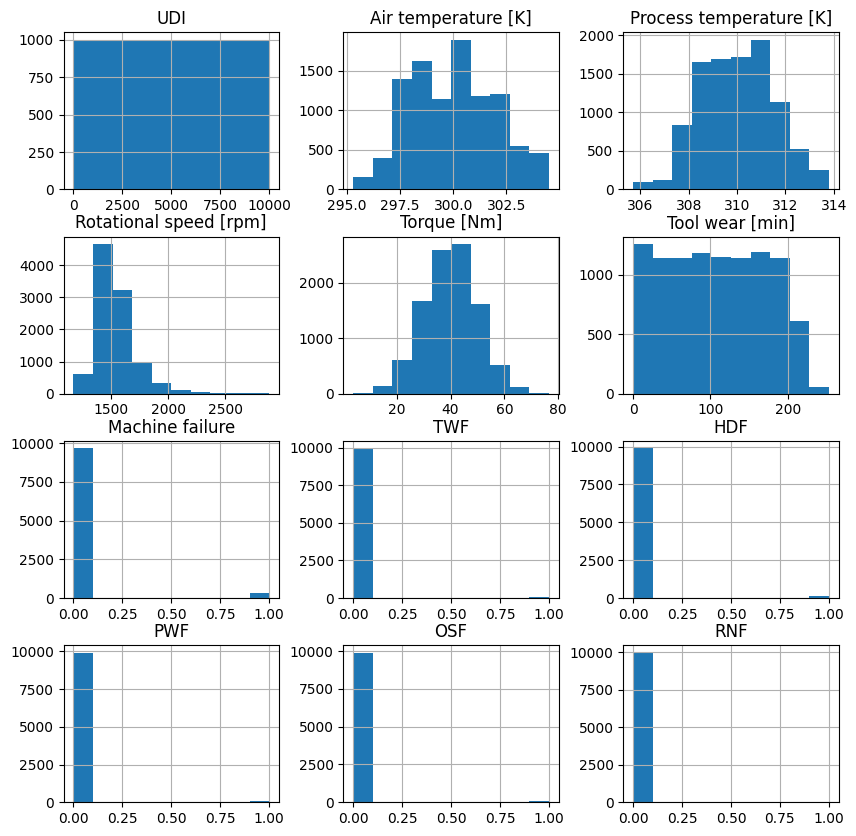

In [5]:
df.hist(figsize=(10,10))

In [6]:
# check all columns name
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
df['Machine failure'].unique()

array([0, 1])

In [9]:
# count the total values of 0 and 1 for Machinr failure column
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

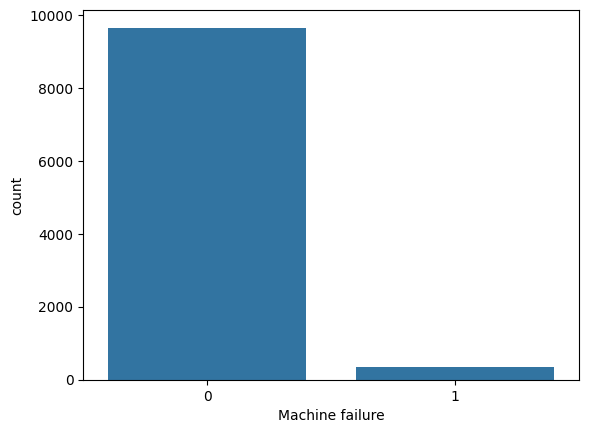

In [10]:
sns.countplot(x="Machine failure", data=df)

In [12]:
# Type of failure

failure_col = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
def classify_failure_type(rows):
    for col in failure_col:
        if rows[col] == 1:
            return col
    return "No failure"

In [14]:
df["Failure Type"] = df.apply(classify_failure_type, axis=1)
df["Failure Type"]

0       No failure
1       No failure
2       No failure
3       No failure
4       No failure
           ...    
9995    No failure
9996    No failure
9997    No failure
9998    No failure
9999    No failure
Name: Failure Type, Length: 10000, dtype: object

<Axes: xlabel='Failure Type', ylabel='count'>

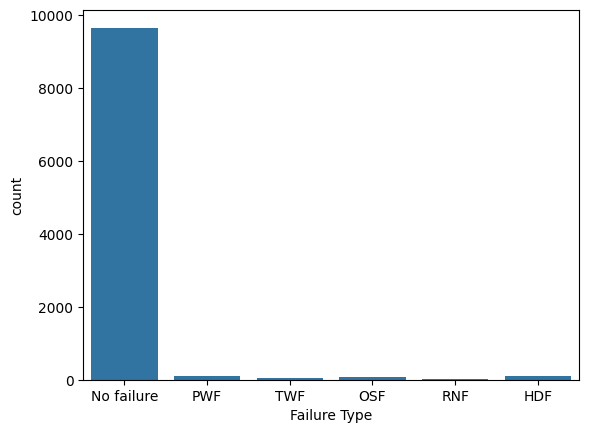

In [ ]:
sns.countplot(x="Failure Type", data=df)

<Axes: xlabel='Type', ylabel='count'>

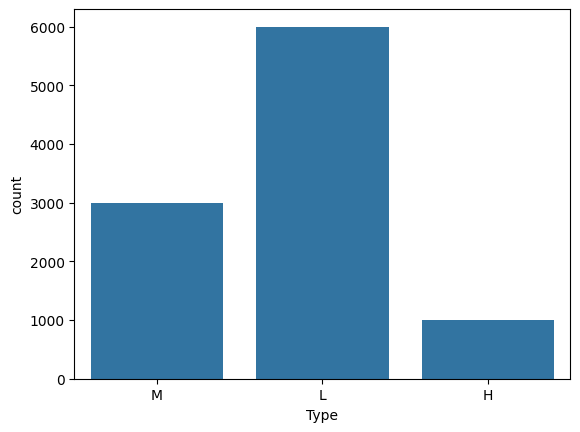

In [16]:
sns.countplot(x="Type", data=df)

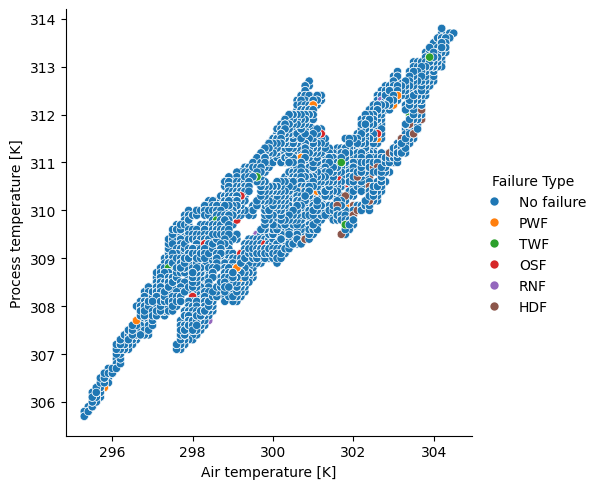

In [19]:
sns.relplot(x="Air temperature [K]", y="Process temperature [K]", hue="Failure Type", sizes=(100,5), data=df)

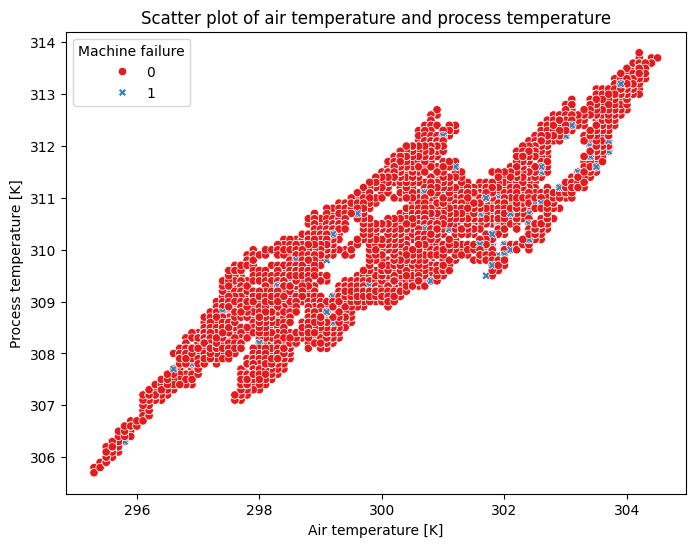

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Air temperature [K]", y="Process temperature [K]", 
    hue="Machine failure", style="Machine failure",
    palette="Set1", data=df
)

plt.title("Scatter plot of air temperature and process temperature")
plt.show()

In [21]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure Type'],
      dtype='object')

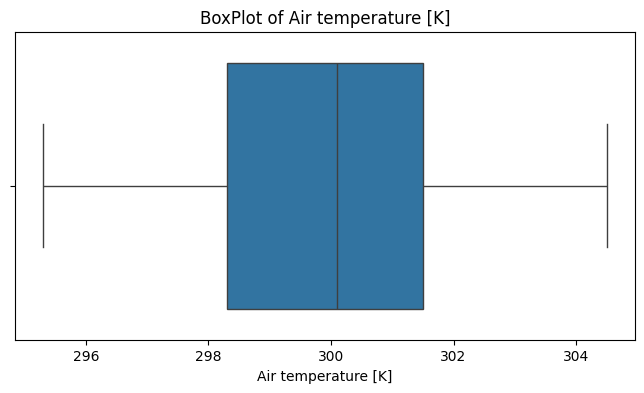

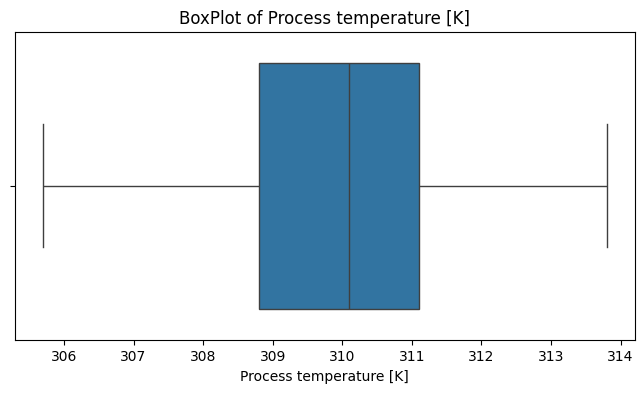

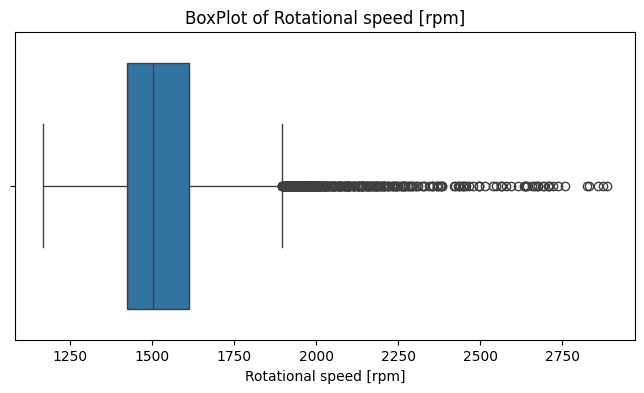

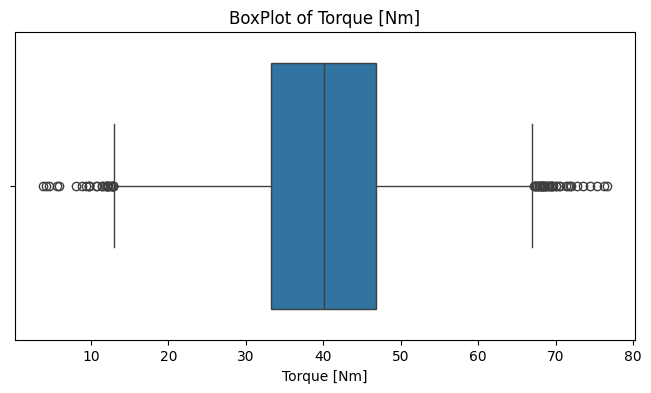

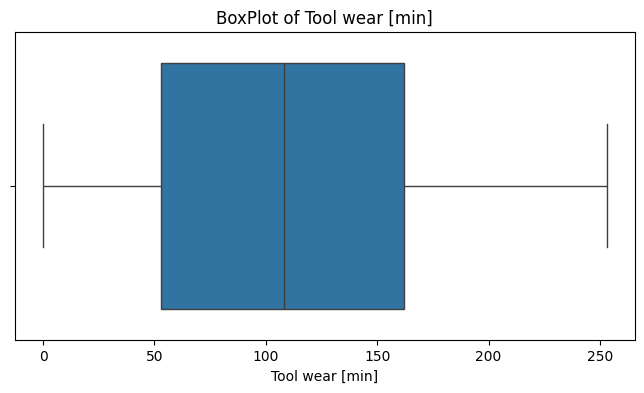

In [22]:
# Outlier detection

sensor_col = ['Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]']

for col in sensor_col:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"BoxPlot of {col}")
    plt.show()

## **Narrative**
#### **Torque and Rotation Speed had more outliers or points outside their normal range qualities**



#### Feature Engineering and ML

In [23]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure Type'],
      dtype='object')

In [24]:
feature_col = ['Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]']
Xfeatures = df[feature_col]
ylabels = df['Machine failure']

In [25]:
# Load ML pkges

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression 

In [35]:
from sklearn.preprocessing import LabelEncoder

Xfeatures = pd.get_dummies(Xfeatures, columns=['Type'])
# Encode labels
le = LabelEncoder()
ylabels_encoded = le.fit_transform(ylabels)

x_train, x_test, y_train, y_test = train_test_split(Xfeatures, ylabels_encoded, test_size=0.25, random_state=42) 

In [42]:
logger.info(f"X Feature data types with all columns: {Xfeatures.dtypes}")
logger.info(f"ylabels unique values:  {ylabels.unique()}")

INFO:__main__:X Feature data types with all columns: Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type_H                        bool
Type_L                        bool
Type_M                        bool
dtype: object
INFO:__main__:ylabels unique values:  [0 1]


In [37]:
# Build Model

def build_model(classifier, x_train, y_train):
    classifier.fit(x_train, y_train)
    return classifier


In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf = build_model(rf, x_train, y_train)

In [39]:
# Check the accuracy
rf_clf.score(x_test, y_test)

0.9856

In [44]:
y_pred = rf_clf.predict(x_test)

In [45]:
# Model Evalutions

logger.info(f"Model Evalutation {classification_report(y_test, y_pred)}")

INFO:__main__:Model Evalutation               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2428
           1       0.89      0.57      0.69        72

    accuracy                           0.99      2500
   macro avg       0.94      0.78      0.84      2500
weighted avg       0.98      0.99      0.98      2500



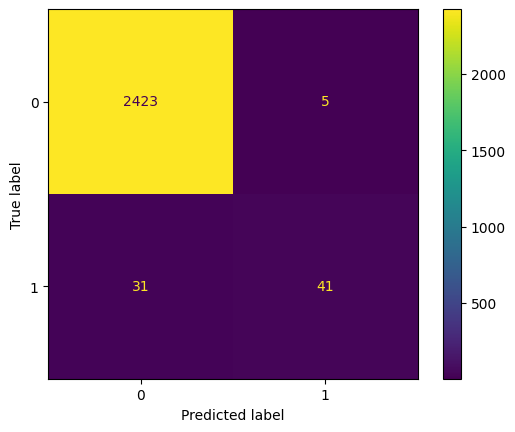

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)

disp.plot()
plt.show()

In [48]:
# Logistic Regression

lr = LogisticRegression()
lr_clf = build_model(lr, x_train, y_train)

c:\Users\vivek\PycharmProjects\pythonProject\Vivekcode\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# Check the accuracy
lr_clf.score(x_test, y_test)

0.9752

In [50]:
y_pred = lr_clf.predict(x_test)

In [51]:
# Model Evalutions

logger.info(f"Model Evalutation {classification_report(y_test, y_pred)}")

INFO:__main__:Model Evalutation               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2428
           1       0.67      0.28      0.39        72

    accuracy                           0.98      2500
   macro avg       0.82      0.64      0.69      2500
weighted avg       0.97      0.98      0.97      2500



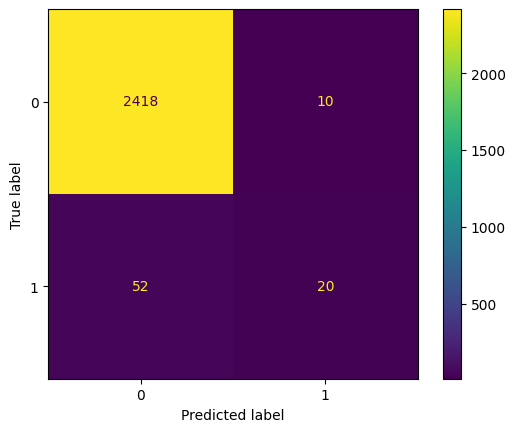

In [52]:
cm = confusion_matrix(y_test, y_pred, labels=lr_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_clf.classes_)

disp.plot()
plt.show()

In [57]:
sample_data = x_test.iloc[20]

logger.info(f"RF Prediction {rf_clf.predict([sample_data])}")
logger.info(f"LR Prediction {lr_clf.predict([sample_data])}")

c:\Users\vivek\PycharmProjects\pythonProject\Vivekcode\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
INFO:__main__:RF Prediction [0]
c:\Users\vivek\PycharmProjects\pythonProject\Vivekcode\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
INFO:__main__:LR Prediction [0]


In [54]:
# Model Interpretation
import eli5

#### Show the most important features or weights used for prediciton

In [55]:
eli5.show_weights(lr_clf, feature_names=Xfeatures.columns.to_list())

Weight?,Feature
+0.831,Air temperature [K]
+0.367,Type_L
+0.277,Torque [Nm]
+0.037,Type_M
+0.013,Tool wear [min]
+0.011,Rotational speed [rpm]
-0.015,<BIAS>
-0.419,Type_H
-0.917,Process temperature [K]


In [56]:
# Model Agnostic

from eli5.sklearn import PermutationImportance
perm = PermutationImportance(lr_clf, random_state=42).fit(x_test, y_test)
eli5.show_weights(perm, feature_names=Xfeatures.columns.to_list())

Weight,Feature
0.0848 ± 0.0026,Torque [Nm]
0.0546 ± 0.0096,Rotational speed [rpm]
0.0247 ± 0.0030,Process temperature [K]
0.0246 ± 0.0061,Air temperature [K]
0.0018 ± 0.0023,Tool wear [min]
0.0003 ± 0.0003,Type_H
0.0002 ± 0.0006,Type_L
0.0001 ± 0.0003,Type_M


In [58]:
# Explain a single prediction
eli5.show_prediction(lr_clf, sample_data, feature_names=Xfeatures.columns.to_list())

In [3]:
list_a = [1, 2, 'a', 4]
list_b =[]
try:
    for i in list_a:
        i = i + 1
        list_b.append(i)
    print(list_b)
except Exception as e:
    print(f"Got the error: {e}")
    
    


Got the error: can only concatenate str (not "int") to str


#### Create a list (1,1), (2,1), (2,2), (3,1), (3,2), (3,3) with the given input as 3 or any other number to generate this list. Use the list comprehension 

In [9]:
write_an_input = int(input("Enter the number: "))

list_new = []
for i in range(1, write_an_input+1):
    value_of_first = i
    for j in range(1, value_of_first+1):
        value = (i,j)
        list_new.append(value)
print(list_new, sep=", ")


[(1, 1), (2, 1), (2, 2), (3, 1), (3, 2), (3, 3)]


In [10]:
n = int(input("Enter the number: "))

pairs = lambda n: [(i, j) for i in range(1, n + 1) for j in range(1, i + 1)]

print(*pairs(n), sep=", ")

(1, 1), (2, 1), (2, 2), (3, 1), (3, 2), (3, 3)
